# Segmentation Comparison: Felzenszwalb vs SLIC

Сравнение классических методов сегментации из scikit-image:
- **Felzenszwalb** - graph-based сегментация
- **SLIC** - superpixel сегментация

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
from skimage.segmentation import felzenszwalb, slic, mark_boundaries
from skimage.color import label2rgb
from skimage.util import img_as_float

print("Imports loaded!")

Imports loaded!


Found 47 frames in /home/denis_fatykhov/Projects/vizEnc/data/scand_spot_fountain-lib/output_frames
Using frame: frame_000000_t0.000.png
Image shape: (720, 1280, 3)


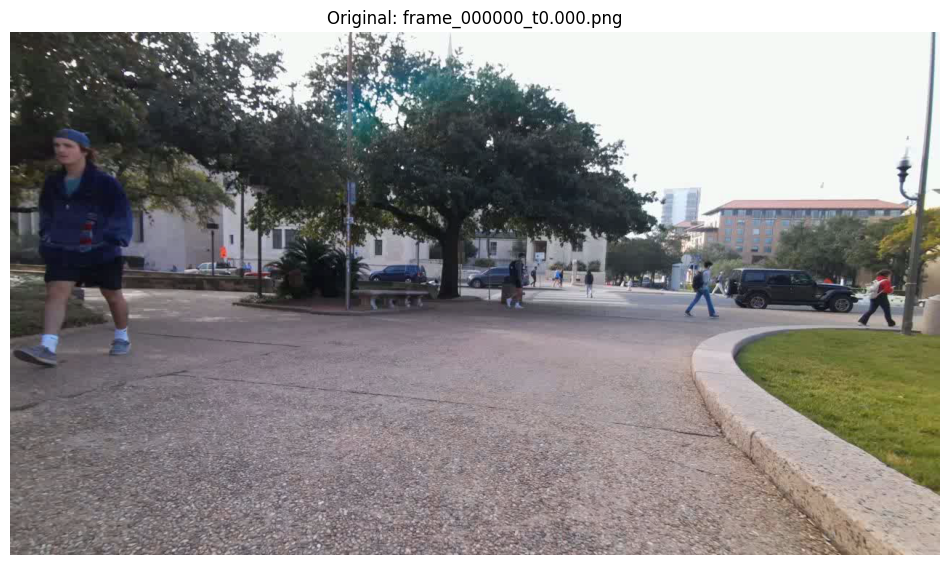

In [3]:
# Load frames
projectDir = Path.cwd().parent
dataDir = projectDir / "data/scand_spot_fountain-lib/output_frames"

frames = sorted(dataDir.glob("frame_*.png"))
print(f"Found {len(frames)} frames in {dataDir}")

# Select frame for comparison
FRAME_IDX = 0
frame_path = frames[FRAME_IDX]
image = np.array(Image.open(frame_path).convert("RGB"))
image_float = img_as_float(image)

print(f"Using frame: {frame_path.name}")
print(f"Image shape: {image.shape}")

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title(f"Original: {frame_path.name}")
plt.axis('off')
plt.show()

## 1. Felzenszwalb Segmentation

Graph-based сегментация. Параметры:
- `scale` - выше = крупнее сегменты
- `sigma` - размытие перед сегментацией
- `min_size` - минимальный размер сегмента

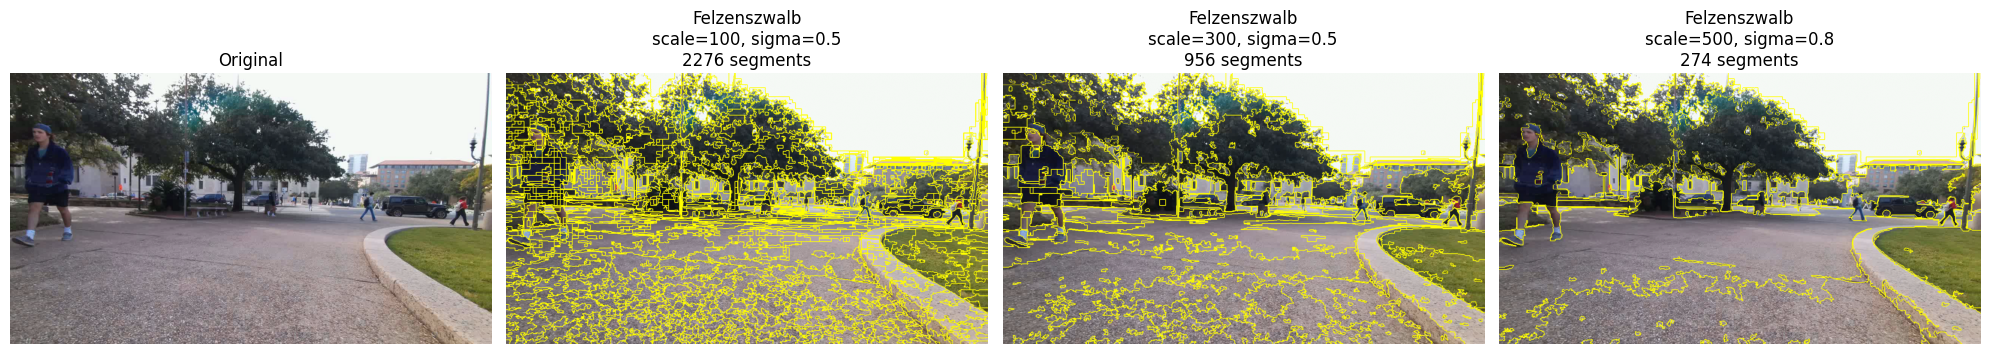

In [4]:
# Felzenszwalb с разными параметрами
felz_params = [
    {'scale': 100, 'sigma': 0.5, 'min_size': 50},
    {'scale': 300, 'sigma': 0.5, 'min_size': 50},
    {'scale': 500, 'sigma': 0.8, 'min_size': 100},
]

fig, axes = plt.subplots(1, len(felz_params) + 1, figsize=(20, 6))

axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

for i, params in enumerate(felz_params):
    segments = felzenszwalb(image_float, **params)
    n_segments = len(np.unique(segments))
    
    axes[i+1].imshow(mark_boundaries(image, segments, color=(1, 1, 0)))
    axes[i+1].set_title(f"Felzenszwalb\nscale={params['scale']}, sigma={params['sigma']}\n{n_segments} segments")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

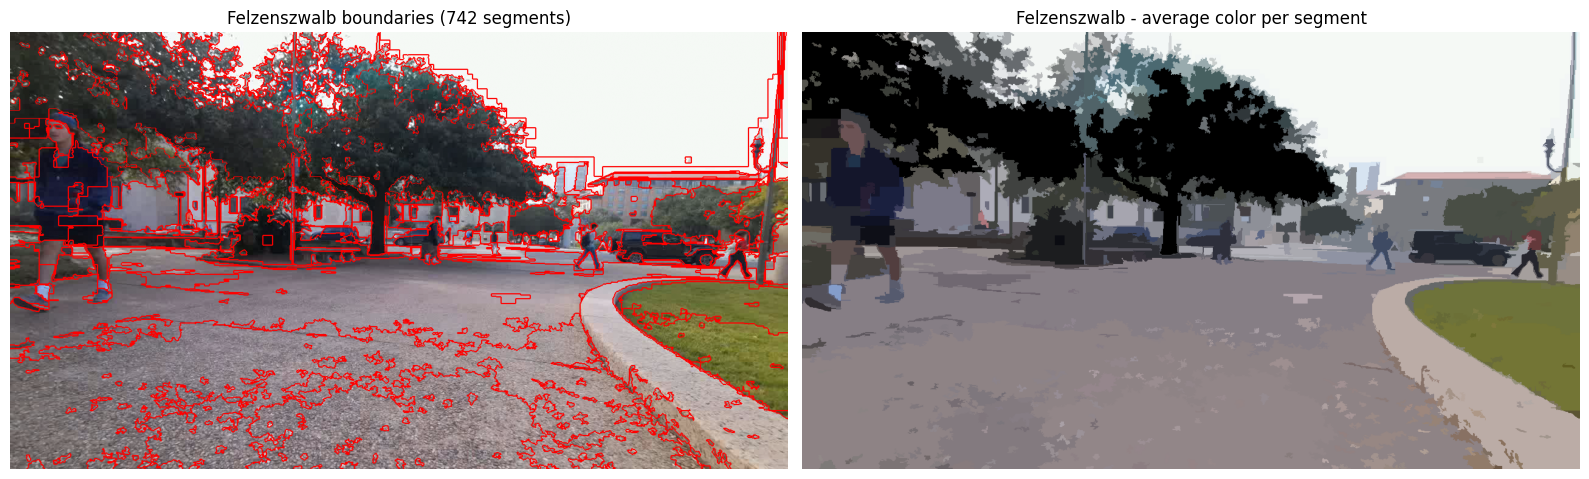

In [8]:
# Лучший вариант Felzenszwalb с цветной визуализацией
segments_felz = felzenszwalb(image_float, scale=400, sigma=0.5, min_size=50)
n_felz = len(np.unique(segments_felz))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(mark_boundaries(image, segments_felz, color=(1, 0, 0)))
axes[0].set_title(f'Felzenszwalb boundaries ({n_felz} segments)')
axes[0].axis('off')

axes[1].imshow(label2rgb(segments_felz, image, kind='avg'))
axes[1].set_title('Felzenszwalb - average color per segment')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. SLIC Superpixels

Simple Linear Iterative Clustering. Параметры:
- `n_segments` - целевое количество superpixels
- `compactness` - баланс между цветом и пространством (выше = более квадратные)
- `sigma` - размытие

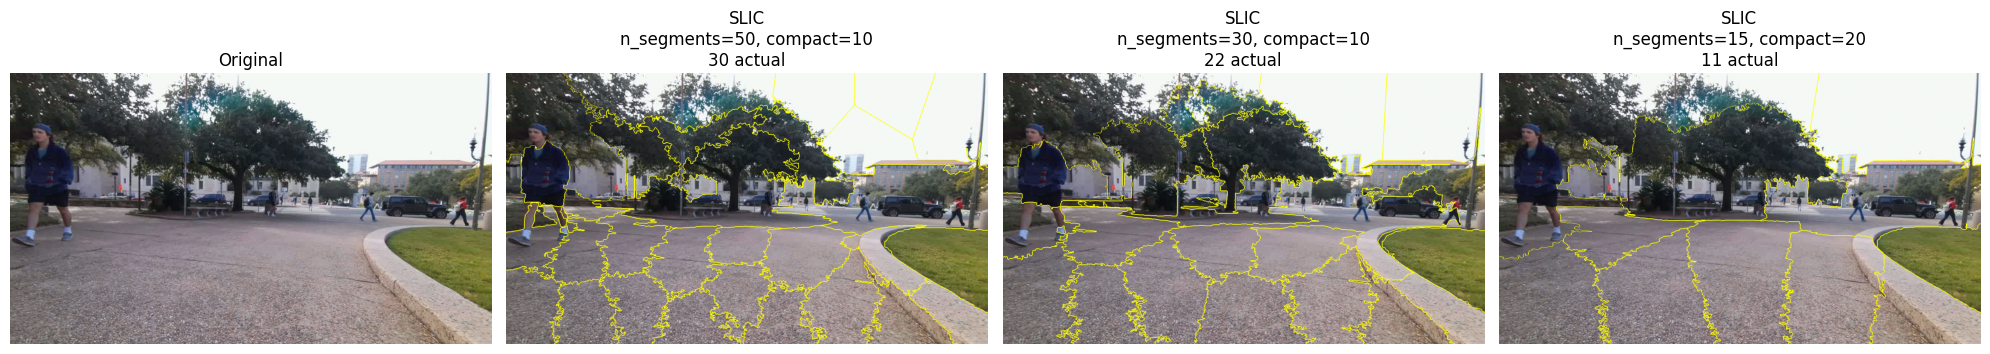

In [12]:
# SLIC с разными параметрами
slic_params = [
    {'n_segments': 50, 'compactness': 10, 'sigma': 1},
    {'n_segments': 30, 'compactness': 10, 'sigma': 1},
    {'n_segments': 15, 'compactness': 20, 'sigma': 1},
]

fig, axes = plt.subplots(1, len(slic_params) + 1, figsize=(20, 6))

axes[0].imshow(image)
axes[0].set_title('Original')
axes[0].axis('off')

for i, params in enumerate(slic_params):
    segments = slic(image_float, **params, start_label=0)
    n_segments = len(np.unique(segments))
    
    axes[i+1].imshow(mark_boundaries(image, segments, color=(1, 1, 0)))
    axes[i+1].set_title(f"SLIC\nn_segments={params['n_segments']}, compact={params['compactness']}\n{n_segments} actual")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

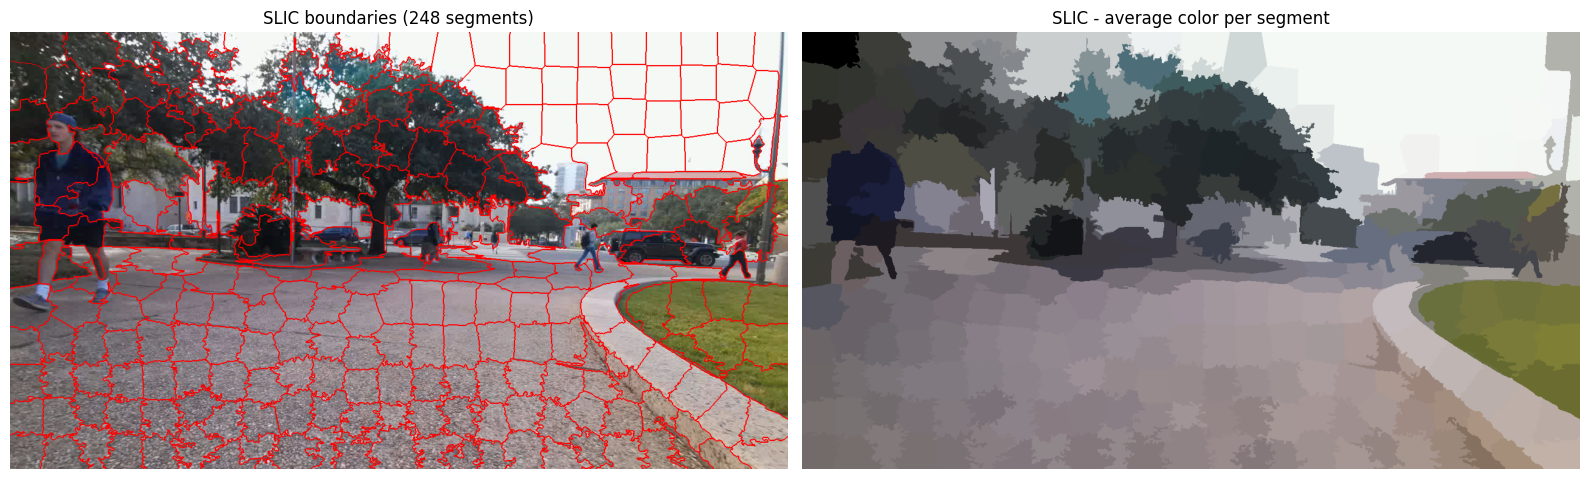

In [13]:
# Лучший вариант SLIC с цветной визуализацией
segments_slic = slic(image_float, n_segments=300, compactness=10, sigma=1, start_label=0)
n_slic = len(np.unique(segments_slic))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(mark_boundaries(image, segments_slic, color=(1, 0, 0)))
axes[0].set_title(f'SLIC boundaries ({n_slic} segments)')
axes[0].axis('off')

axes[1].imshow(label2rgb(segments_slic, image, kind='avg'))
axes[1].set_title('SLIC - average color per segment')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Side-by-Side Comparison

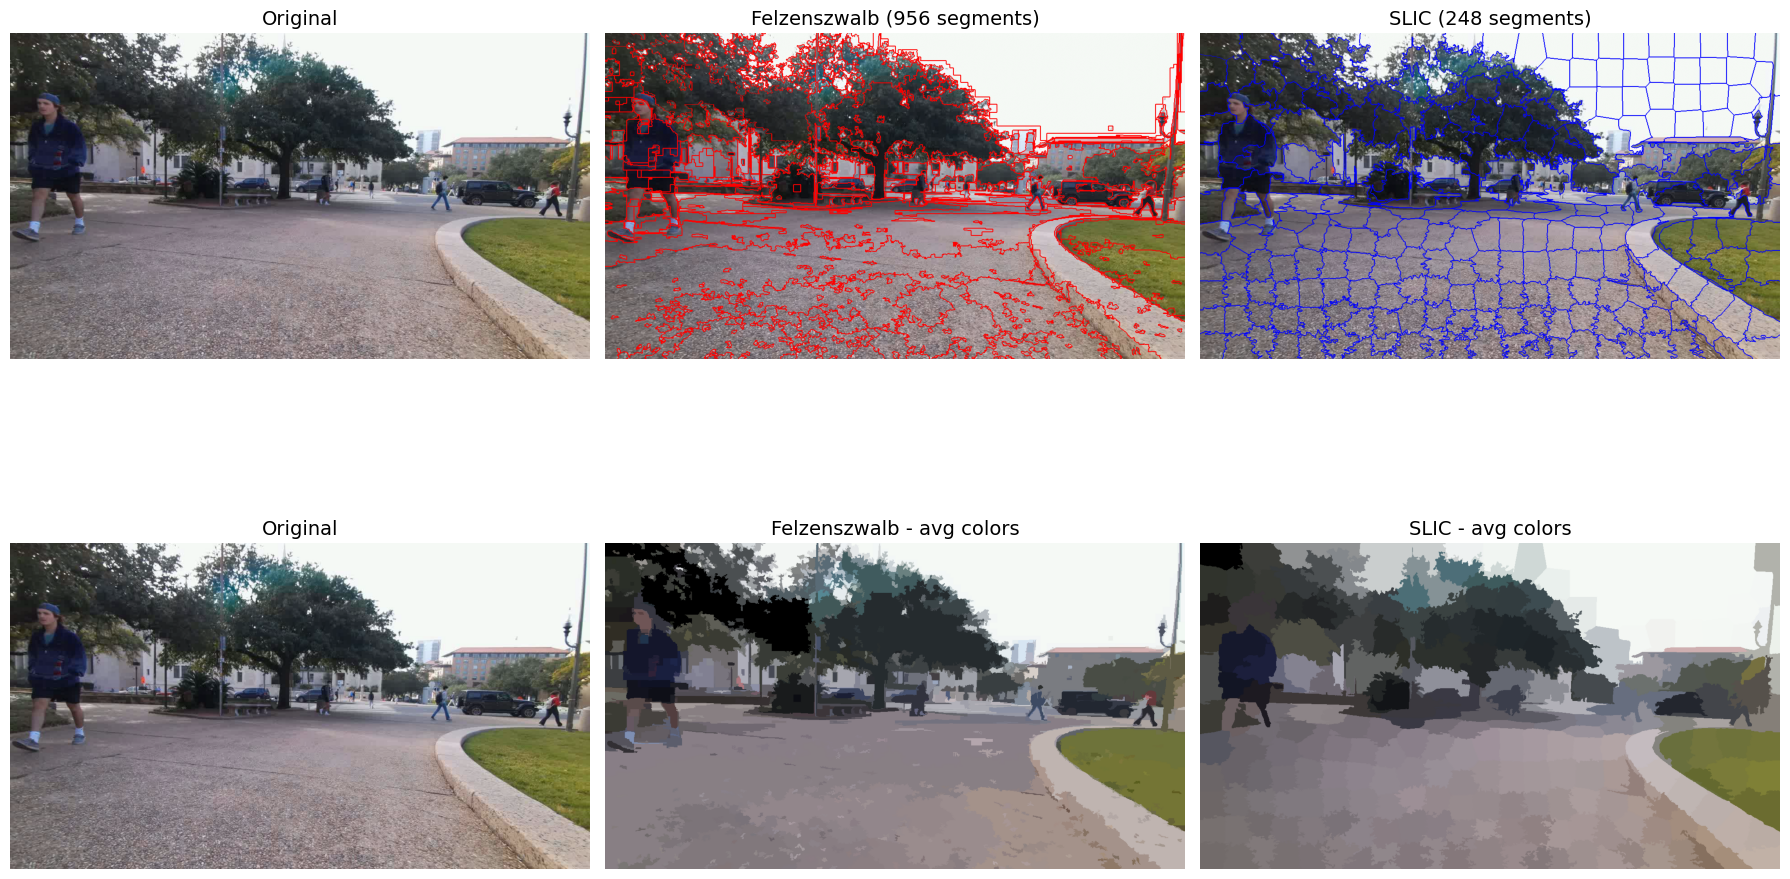

In [14]:
# Финальное сравнение
segments_felz = felzenszwalb(image_float, scale=300, sigma=0.5, min_size=50)
segments_slic = slic(image_float, n_segments=300, compactness=10, sigma=1, start_label=0)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: boundaries
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(mark_boundaries(image, segments_felz, color=(1, 0, 0)))
axes[0, 1].set_title(f'Felzenszwalb ({len(np.unique(segments_felz))} segments)', fontsize=14)
axes[0, 1].axis('off')

axes[0, 2].imshow(mark_boundaries(image, segments_slic, color=(0, 0, 1)))
axes[0, 2].set_title(f'SLIC ({len(np.unique(segments_slic))} segments)', fontsize=14)
axes[0, 2].axis('off')

# Row 2: colored segments
axes[1, 0].imshow(image)
axes[1, 0].set_title('Original', fontsize=14)
axes[1, 0].axis('off')

axes[1, 1].imshow(label2rgb(segments_felz, image, kind='avg'))
axes[1, 1].set_title('Felzenszwalb - avg colors', fontsize=14)
axes[1, 1].axis('off')

axes[1, 2].imshow(label2rgb(segments_slic, image, kind='avg'))
axes[1, 2].set_title('SLIC - avg colors', fontsize=14)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


Felzenszwalb:
  Total segments: 956
  Avg segment size: 964 pixels
  Min segment size: 50 pixels
  Max segment size: 103115 pixels
  Median segment size: 138 pixels

SLIC:
  Total segments: 248
  Avg segment size: 3716 pixels
  Min segment size: 1549 pixels
  Max segment size: 13890 pixels
  Median segment size: 3426 pixels


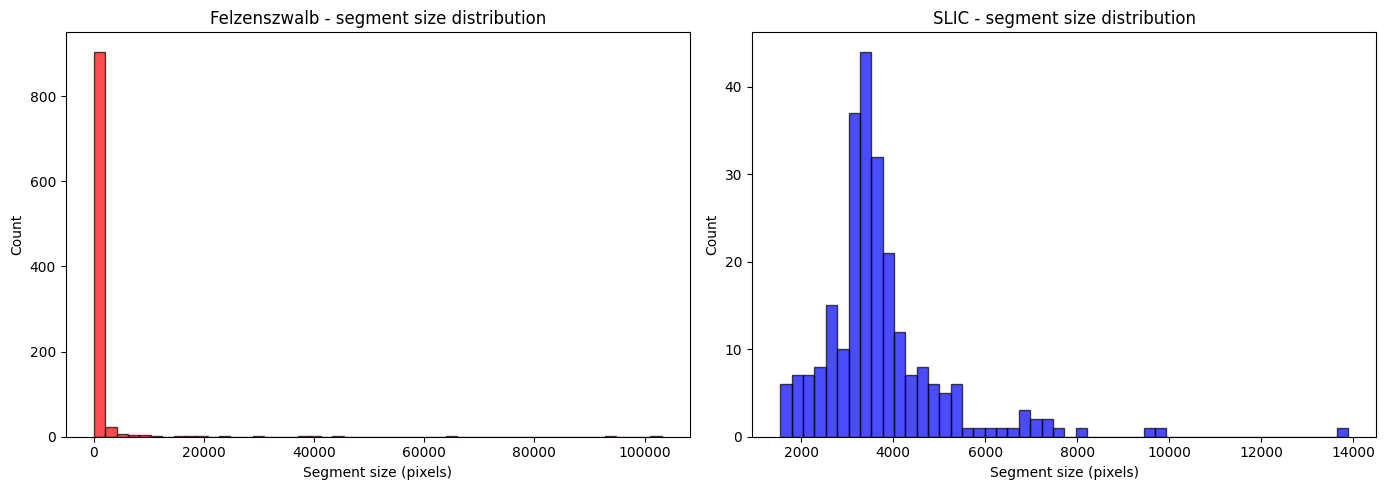

In [15]:
# Статистика сегментов
from collections import Counter

def segment_stats(segments, name):
    unique, counts = np.unique(segments, return_counts=True)
    total_pixels = segments.size
    
    print(f"\n{name}:")
    print(f"  Total segments: {len(unique)}")
    print(f"  Avg segment size: {counts.mean():.0f} pixels")
    print(f"  Min segment size: {counts.min()} pixels")
    print(f"  Max segment size: {counts.max()} pixels")
    print(f"  Median segment size: {np.median(counts):.0f} pixels")
    
    return counts

felz_counts = segment_stats(segments_felz, "Felzenszwalb")
slic_counts = segment_stats(segments_slic, "SLIC")

# Гистограмма размеров
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(felz_counts, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Felzenszwalb - segment size distribution')
axes[0].set_xlabel('Segment size (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(slic_counts, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('SLIC - segment size distribution')
axes[1].set_xlabel('Segment size (pixels)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Summary

| Method | Pros | Cons |
|--------|------|------|
| **Felzenszwalb** | Адаптивный размер сегментов, следует границам объектов | Нестабильное количество сегментов |
| **SLIC** | Равномерные superpixels, контролируемое количество | Не следует границам объектов |